In [1]:
!pip -q install -U transformers datasets accelerate peft trl sentencepiece evaluate rouge_score bert-score huggingface_hub bitsandbytes

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.0/678.0 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 53.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import json
import math
import random
import numpy as np
import pandas as pd
import torch
from transformers import BitsAndBytesConfig
from peft import prepare_model_for_kbit_training

from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
login(HF_TOKEN)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print("BF16 supported:", torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False)

GPU: NVIDIA A100-SXM4-80GB
BF16 supported: True


In [25]:
MODEL_ID = "google/gemma-1.1-2b-it"
DATASET_REPO = "BSVGK/drugbank_dataset"

DATA_FILES = {
    "train": "kg_to_text_train.jsonl",
    "validation": "kg_to_text_validation.jsonl",
    "test": "kg_to_text_test.jsonl"
}

OUTPUT_DIR = "/content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/QLORA_OUTPUTS"
ADAPTER_DIR = f"{OUTPUT_DIR}/adapter"
MERGED_DIR = f"{OUTPUT_DIR}/merged"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ADAPTER_DIR, exist_ok=True)
os.makedirs(MERGED_DIR, exist_ok=True)

COMMON_EPOCHS = 3
COMMON_LR = 2e-4
COMMON_WEIGHT_DECAY = 0.01
COMMON_WARMUP_RATIO = 0.03
COMMON_TRAIN_BATCH_SIZE = 2
COMMON_EVAL_BATCH_SIZE = 1
COMMON_GRAD_ACCUM = 8
COMMON_LOGGING_STEPS = 10
COMMON_EVAL_STEPS = 50
COMMON_SAVE_STEPS = 50
COMMON_SAVE_TOTAL_LIMIT = 2

COMMON_LORA_R = 16
COMMON_LORA_ALPHA = 32
COMMON_LORA_DROPOUT = 0.05

In [5]:
from datasets import load_dataset

raw_ds = load_dataset(
    DATASET_REPO,
    data_files=DATA_FILES,
    token=HF_TOKEN
)

print(raw_ds)

kg_to_text_train.jsonl: 0.00B [00:00, ?B/s]

kg_to_text_validation.jsonl: 0.00B [00:00, ?B/s]

kg_to_text_test.jsonl: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 2029
    })
    validation: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 254
    })
    test: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 254
    })
})


In [6]:
print("Train size:", len(raw_ds["train"]))
print("Validation size:", len(raw_ds["validation"]))
print("Test size:", len(raw_ds["test"]))

print("\nColumns:", raw_ds["train"].column_names)

print("\nTrain sample:")
print(raw_ds["train"][0])

print("\nValidation sample:")
print(raw_ds["validation"][0])

print("\nTest sample:")
print(raw_ds["test"][0])

Train size: 2029
Validation size: 254
Test size: 254

Columns: ['instruction', 'input', 'output']

Train sample:
{'instruction': 'Convert the following drug knowledge graph triples into a clear and complete natural language description.', 'input': '(DB00006, rdf:type, Drug)\n(DB00006, hasName, Bivalirudin)\n(DB00006, hasDrugBankID, DB00006)\n(DB00006, hasSynonym, Bivalirudin)\n(DB00006, hasSynonym, Bivalirudina)\n(DB00006, hasGroup, approved)\n(DB00006, hasGroup, investigational)\n(DB00006, hasState, solid)\n(DB00006, hasDescription, Bivalirudin is a synthetic 20 residue peptide (thrombin inhibitor) which reversibly inhibits thrombin.)\n(DB00006, hasIndication, For treatment of heparin-induced thrombocytopenia and for the prevention of thrombosis.)\n(DB00006, hasMechanismOfAction, Inhibits the action of thrombin by binding both to its catalytic site and to its anion-binding exosite.)\n(DB00006, hasUNII, TN9BEX005G)\n(DB00006, hasCASNumber, 128270-60-0)\n(DB00006, hasAverageMass, 2180.2

In [7]:
def basic_dataset_check(ds, split_name):
    df = pd.DataFrame(ds[split_name])

    print(f"\n===== {split_name.upper()} =====")
    print("Rows:", len(df))
    print("Null counts:")
    print(df[["instruction", "input", "output"]].isnull().sum())

    print("\nEmpty string counts:")
    for col in ["instruction", "input", "output"]:
        empty_count = (df[col].astype(str).str.strip() == "").sum()
        print(f"{col}: {empty_count}")

    print("\nDuplicate full rows:", df.duplicated().sum())

    df["input_words"] = df["input"].astype(str).apply(lambda x: len(x.split()))
    df["output_words"] = df["output"].astype(str).apply(lambda x: len(x.split()))

    print("\nInput word stats:")
    print(df["input_words"].describe())

    print("\nOutput word stats:")
    print(df["output_words"].describe())

basic_dataset_check(raw_ds, "train")
basic_dataset_check(raw_ds, "validation")
basic_dataset_check(raw_ds, "test")


===== TRAIN =====
Rows: 2029
Null counts:
instruction    0
input          0
output         0
dtype: int64

Empty string counts:
instruction: 0
input: 0
output: 0

Duplicate full rows: 0

Input word stats:
count    2029.000000
mean       94.082799
std        13.979876
min        59.000000
25%        84.000000
50%        94.000000
75%       104.000000
max       131.000000
Name: input_words, dtype: float64

Output word stats:
count    2029.000000
mean      117.547068
std        14.593012
min        75.000000
25%       107.000000
50%       118.000000
75%       128.000000
max       157.000000
Name: output_words, dtype: float64

===== VALIDATION =====
Rows: 254
Null counts:
instruction    0
input          0
output         0
dtype: int64

Empty string counts:
instruction: 0
input: 0
output: 0

Duplicate full rows: 0

Input word stats:
count    254.000000
mean      95.948819
std       13.459401
min       54.000000
25%       86.000000
50%       97.000000
75%      105.000000
max      127.000000

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

print("Pad token:", tokenizer.pad_token)
print("Pad token id:", tokenizer.pad_token_id)

config.json:   0%|          | 0.00/618 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Pad token: <pad>
Pad token id: 0


In [9]:
START_USER = "<start_of_turn>user\n"
START_MODEL = "<start_of_turn>model\n"
END_TURN = "<end_of_turn>"

def build_prompt(example):
    instruction = str(example["instruction"]).strip()
    input_text = str(example["input"]).strip()

    prompt = (
        f"{START_USER}"
        f"{instruction}\n\n"
        f"{input_text}"
        f"{END_TURN}\n"
        f"{START_MODEL}"
    )
    return prompt

def build_response(example):
    return str(example["output"]).strip() + END_TURN

def format_example(example):
    prompt = build_prompt(example)
    response = build_response(example)
    text = prompt + response
    return {
        "prompt": prompt,
        "response": response,
        "text": text
    }

formatted_ds = raw_ds.map(format_example)

Map:   0%|          | 0/2029 [00:00<?, ? examples/s]

Map:   0%|          | 0/254 [00:00<?, ? examples/s]

Map:   0%|          | 0/254 [00:00<?, ? examples/s]

In [10]:
print("Formatted train example:\n")
print(formatted_ds["train"][0]["text"][:3000])

print("\nPrompt only:\n")
print(formatted_ds["train"][0]["prompt"][:1500])

print("\nResponse only:\n")
print(formatted_ds["train"][0]["response"][:1500])

Formatted train example:

<start_of_turn>user
Convert the following drug knowledge graph triples into a clear and complete natural language description.

(DB00006, rdf:type, Drug)
(DB00006, hasName, Bivalirudin)
(DB00006, hasDrugBankID, DB00006)
(DB00006, hasSynonym, Bivalirudin)
(DB00006, hasSynonym, Bivalirudina)
(DB00006, hasGroup, approved)
(DB00006, hasGroup, investigational)
(DB00006, hasState, solid)
(DB00006, hasDescription, Bivalirudin is a synthetic 20 residue peptide (thrombin inhibitor) which reversibly inhibits thrombin.)
(DB00006, hasIndication, For treatment of heparin-induced thrombocytopenia and for the prevention of thrombosis.)
(DB00006, hasMechanismOfAction, Inhibits the action of thrombin by binding both to its catalytic site and to its anion-binding exosite.)
(DB00006, hasUNII, TN9BEX005G)
(DB00006, hasCASNumber, 128270-60-0)
(DB00006, hasAverageMass, 2180.2853)
(DB00006, hasMonoisotopicMass, 2178.985813062)<end_of_turn>
<start_of_turn>model
Bivalirudin is a drug 

In [11]:
def get_token_lengths(example):
    prompt_ids = tokenizer(example["prompt"], add_special_tokens=False)["input_ids"]
    response_ids = tokenizer(example["response"], add_special_tokens=False)["input_ids"]
    text_ids = tokenizer(example["text"], add_special_tokens=False)["input_ids"]

    return {
        "prompt_tokens": len(prompt_ids),
        "response_tokens": len(response_ids),
        "total_tokens": len(text_ids)
    }

length_ds = formatted_ds.map(get_token_lengths)

def show_length_stats(split_name):
    df = pd.DataFrame({
        "prompt_tokens": length_ds[split_name]["prompt_tokens"],
        "response_tokens": length_ds[split_name]["response_tokens"],
        "total_tokens": length_ds[split_name]["total_tokens"]
    })

    print(f"\n===== {split_name.upper()} TOKEN STATS =====")
    print(df.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))
    return df

train_len_df = show_length_stats("train")
val_len_df = show_length_stats("validation")
test_len_df = show_length_stats("test")

Map:   0%|          | 0/2029 [00:00<?, ? examples/s]

Map:   0%|          | 0/254 [00:00<?, ? examples/s]

Map:   0%|          | 0/254 [00:00<?, ? examples/s]


===== TRAIN TOKEN STATS =====
       prompt_tokens  response_tokens  total_tokens
count        2029.00          2029.00       2029.00
mean          382.00           221.63        603.63
std            40.70            33.22         70.92
min           293.00           143.00        436.00
50%           378.00           219.00        597.00
90%           432.00           267.00        701.00
95%           456.00           282.00        735.20
99%           506.44           312.72        803.72
max           634.00           361.00        877.00

===== VALIDATION TOKEN STATS =====
       prompt_tokens  response_tokens  total_tokens
count         254.00           254.00        254.00
mean          384.78           223.46        608.23
std            39.57            33.59         69.88
min           300.00           151.00        451.00
50%           380.50           220.00        601.50
90%           432.00           267.70        702.90
95%           449.40           279.00        723.

In [12]:
p99_total = int(np.percentile(train_len_df["total_tokens"], 99))
MAX_SEQ_LENGTH = min(2048, int(math.ceil(p99_total / 64) * 64))
MAX_SEQ_LENGTH = max(512, MAX_SEQ_LENGTH)

print("Chosen MAX_SEQ_LENGTH:", MAX_SEQ_LENGTH)

Chosen MAX_SEQ_LENGTH: 832


In [13]:
def truncation_check(example):
    prompt_ids = tokenizer(example["prompt"], add_special_tokens=False)["input_ids"]
    response_ids = tokenizer(example["response"], add_special_tokens=False)["input_ids"]

    full_len = len(prompt_ids) + len(response_ids)
    is_truncated = full_len > MAX_SEQ_LENGTH

    kept_response_tokens = max(0, MAX_SEQ_LENGTH - len(prompt_ids))
    lost_response_tokens = max(0, len(response_ids) - kept_response_tokens)

    return {
        "full_len": full_len,
        "is_truncated": int(is_truncated),
        "lost_response_tokens": lost_response_tokens
    }

trunc_ds = formatted_ds.map(truncation_check)

for split in ["train", "validation", "test"]:
    df = pd.DataFrame(trunc_ds[split])
    print(f"\n===== {split.upper()} TRUNCATION CHECK =====")
    print("Truncated rows:", df["is_truncated"].sum(), "/", len(df))
    print("Average lost response tokens:", round(df["lost_response_tokens"].mean(), 2))
    print("Max lost response tokens:", df["lost_response_tokens"].max())

Map:   0%|          | 0/2029 [00:00<?, ? examples/s]

Map:   0%|          | 0/254 [00:00<?, ? examples/s]

Map:   0%|          | 0/254 [00:00<?, ? examples/s]


===== TRAIN TRUNCATION CHECK =====
Truncated rows: 9 / 2029
Average lost response tokens: 0.09
Max lost response tokens: 45

===== VALIDATION TRUNCATION CHECK =====
Truncated rows: 2 / 254
Average lost response tokens: 0.35
Max lost response tokens: 88

===== TEST TRUNCATION CHECK =====
Truncated rows: 3 / 254
Average lost response tokens: 0.52
Max lost response tokens: 47


In [14]:
def tokenize_and_mask(example):
    prompt_ids = tokenizer(
        example["prompt"],
        add_special_tokens=False,
        truncation=False
    )["input_ids"]

    response_ids = tokenizer(
        example["response"],
        add_special_tokens=False,
        truncation=False
    )["input_ids"]

    input_ids = prompt_ids + response_ids
    attention_mask = [1] * len(input_ids)

    labels = [-100] * len(prompt_ids) + response_ids.copy()

    input_ids = input_ids[:MAX_SEQ_LENGTH]
    attention_mask = attention_mask[:MAX_SEQ_LENGTH]
    labels = labels[:MAX_SEQ_LENGTH]

    supervised_tokens = sum(1 for x in labels if x != -100)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "supervised_tokens": supervised_tokens
    }

tokenized_ds = formatted_ds.map(
    tokenize_and_mask,
    remove_columns=formatted_ds["train"].column_names
)

Map:   0%|          | 0/2029 [00:00<?, ? examples/s]

Map:   0%|          | 0/254 [00:00<?, ? examples/s]

Map:   0%|          | 0/254 [00:00<?, ? examples/s]

In [15]:
print(tokenized_ds)

sample_tok = tokenized_ds["train"][0]

print("\nInput ids length:", len(sample_tok["input_ids"]))
print("Labels length:", len(sample_tok["labels"]))
print("Supervised tokens:", sample_tok["supervised_tokens"])

print("\nFirst 50 labels:")
print(sample_tok["labels"][:50])

print("\nLast 50 labels:")
print(sample_tok["labels"][-50:])

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels', 'supervised_tokens'],
        num_rows: 2029
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels', 'supervised_tokens'],
        num_rows: 254
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels', 'supervised_tokens'],
        num_rows: 254
    })
})

Input ids length: 553
Labels length: 553
Supervised tokens: 194

First 50 labels:
[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]

Last 50 labels:
[5182, 576, 235248, 235284, 235274, 235324, 235321, 235265, 235315, 235321, 235308, 235321, 235274, 235304, 235276, 235318, 235284, 235265, 9707, 4571, 2694, 603, 35100, 235315, 235

In [16]:
for split in ["train", "validation", "test"]:
    before = len(tokenized_ds[split])
    tokenized_ds[split] = tokenized_ds[split].filter(lambda x: x["supervised_tokens"] > 0)
    after = len(tokenized_ds[split])
    print(f"{split}: kept {after}/{before}")

Filter:   0%|          | 0/2029 [00:00<?, ? examples/s]

train: kept 2029/2029


Filter:   0%|          | 0/254 [00:00<?, ? examples/s]

validation: kept 254/254


Filter:   0%|          | 0/254 [00:00<?, ? examples/s]

test: kept 254/254


In [17]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training

bf16_supported = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
compute_dtype = torch.bfloat16 if bf16_supported else torch.float16

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN,
    quantization_config=bnb_config,
    device_map="auto"
)

model.config.use_cache = False
model = prepare_model_for_kbit_training(model)
model.gradient_checkpointing_enable()

print("QLoRA base model loaded successfully.")

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

QLoRA base model loaded successfully.


In [18]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=COMMON_LORA_R,
    lora_alpha=COMMON_LORA_ALPHA,
    lora_dropout=COMMON_LORA_DROPOUT,
    bias="none",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ]
)

model = get_peft_model(model, lora_config)

def print_trainable_parameters(model):
    trainable_params = 0
    all_params = 0
    for _, param in model.named_parameters():
        all_params += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()

    print(f"Trainable params: {trainable_params:,}")
    print(f"All params: {all_params:,}")
    print(f"Trainable %: {100 * trainable_params / all_params:.4f}")

print_trainable_parameters(model)

Trainable params: 19,611,648
All params: 1,534,879,744
Trainable %: 1.2777


In [19]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    pad_to_multiple_of=8,
    return_tensors="pt"
)

In [20]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    logits = torch.tensor(logits)
    labels = torch.tensor(labels)

    vocab_size = logits.shape[-1]
    logits = logits.view(-1, vocab_size)
    labels = labels.view(-1)

    valid_mask = labels != -100
    logits = logits[valid_mask]
    labels = labels[valid_mask]

    if labels.numel() == 0:
        return {"perplexity": float("nan")}

    loss_fct = torch.nn.CrossEntropyLoss()
    loss = loss_fct(logits, labels)
    ppl = torch.exp(loss).item()

    return {"perplexity": ppl}

In [21]:
from transformers import TrainingArguments

total_train_steps = int(len(tokenized_ds["train"]) / COMMON_TRAIN_BATCH_SIZE / COMMON_GRAD_ACCUM * COMMON_EPOCHS)
warmup_steps = int(total_train_steps * COMMON_WARMUP_RATIO)

training_args = TrainingArguments(
    output_dir= OUTPUT_DIR,
    num_train_epochs=COMMON_EPOCHS,
    learning_rate=COMMON_LR,
    weight_decay=COMMON_WEIGHT_DECAY,
    warmup_steps=warmup_steps,
    per_device_train_batch_size=COMMON_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=COMMON_GRAD_ACCUM,
    logging_strategy="steps",
    logging_steps=COMMON_LOGGING_STEPS,
    eval_strategy="steps",
    eval_steps=COMMON_EVAL_STEPS,
    save_strategy="steps",
    save_steps=COMMON_SAVE_STEPS,
    save_total_limit=COMMON_SAVE_TOTAL_LIMIT,
    bf16=bf16_supported,
    fp16=not bf16_supported,
    gradient_checkpointing=True,
    prediction_loss_only=True,
    lr_scheduler_type="cosine",
    optim="paged_adamw_8bit",
    report_to="none",
    seed=SEED,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    remove_unused_columns=False
)

In [22]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

In [23]:
run_config = {
    "method": "QLoRA",
    "model_id": MODEL_ID,
    "dataset_repo": DATASET_REPO,
    "data_files": DATA_FILES,
    "max_seq_length": MAX_SEQ_LENGTH,
    "seed": SEED,
    "epochs": COMMON_EPOCHS,
    "learning_rate": COMMON_LR,
    "weight_decay": COMMON_WEIGHT_DECAY,
    "warmup_ratio": COMMON_WARMUP_RATIO,
    "train_batch_size": COMMON_TRAIN_BATCH_SIZE,
    "eval_batch_size": COMMON_EVAL_BATCH_SIZE,
    "grad_accum": COMMON_GRAD_ACCUM,
    "lora_r": COMMON_LORA_R,
    "lora_alpha": COMMON_LORA_ALPHA,
    "lora_dropout": COMMON_LORA_DROPOUT
}

with open(os.path.join(OUTPUT_DIR, "run_config.json"), "w") as f:
    json.dump(run_config, f, indent=2)

print("Saved run config.")

Saved run config.


In [24]:
train_result = trainer.train()
print(train_result)

Step,Training Loss,Validation Loss
50,0.024553,0.022567
100,0.014531,0.013943
150,0.009048,0.011495
200,0.008781,0.011561
250,0.007753,0.009762
300,0.005365,0.009781
350,0.005255,0.009715
381,0.005381,0.009744


TrainOutput(global_step=381, training_loss=0.035760006242800804, metrics={'train_runtime': 1504.5989, 'train_samples_per_second': 4.046, 'train_steps_per_second': 0.253, 'total_flos': 4.72474441825321e+16, 'train_loss': 0.035760006242800804, 'epoch': 3.0})


In [26]:
trainer.save_model(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print("Saved QLoRA adapter to:", ADAPTER_DIR)

Saved QLoRA adapter to: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/QLORA_OUTPUTS/adapter


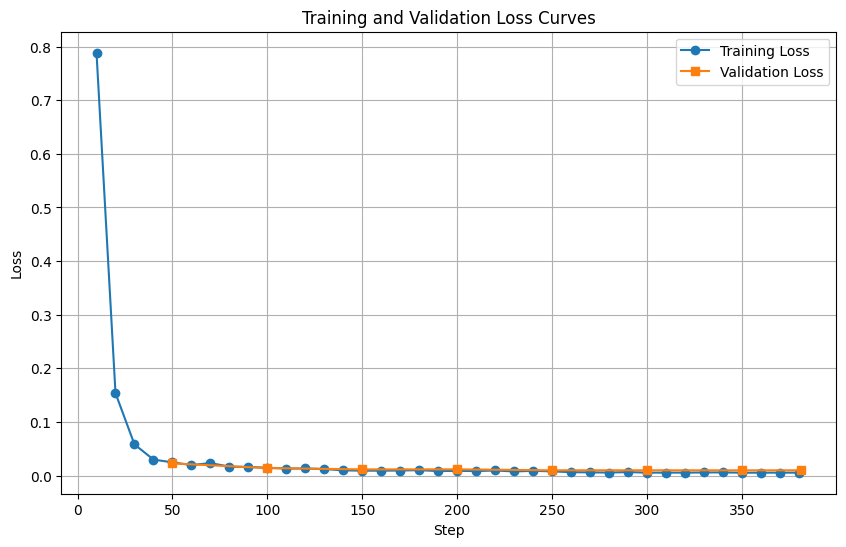

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

logs_df = pd.DataFrame(trainer.state.log_history)

train_logs = logs_df[logs_df["loss"].notna()].copy() if "loss" in logs_df.columns else pd.DataFrame()
eval_logs = logs_df[logs_df["eval_loss"].notna()].copy() if "eval_loss" in logs_df.columns else pd.DataFrame()

plt.figure(figsize=(10, 6))

if not train_logs.empty:
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="Training Loss")

if not eval_logs.empty:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="Validation Loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

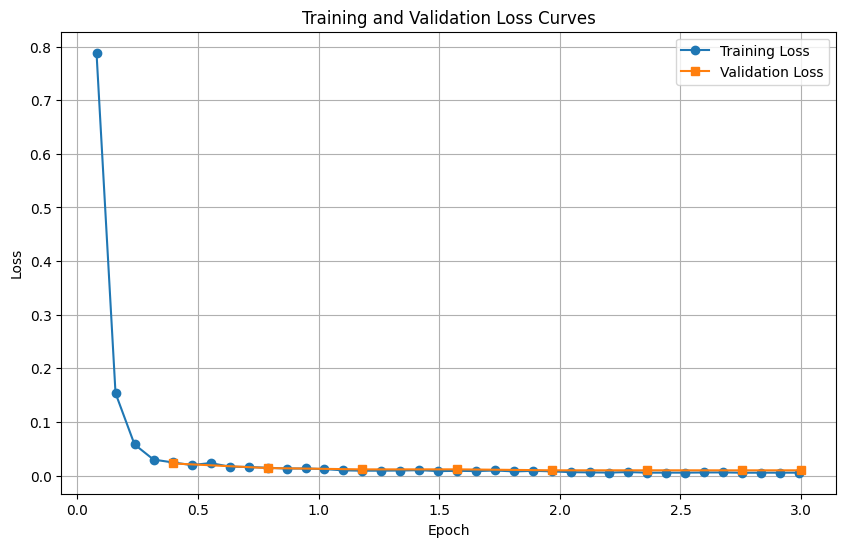

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

logs_df = pd.DataFrame(trainer.state.log_history)

train_logs = logs_df[logs_df["loss"].notna()].copy() if "loss" in logs_df.columns else pd.DataFrame()
eval_logs = logs_df[logs_df["eval_loss"].notna()].copy() if "eval_loss" in logs_df.columns else pd.DataFrame()

plt.figure(figsize=(10, 6))

if not train_logs.empty and "epoch" in train_logs.columns:
    plt.plot(train_logs["epoch"], train_logs["loss"], marker="o", label="Training Loss")

if not eval_logs.empty and "epoch" in eval_logs.columns:
    plt.plot(eval_logs["epoch"], eval_logs["eval_loss"], marker="s", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
test_example = raw_ds["test"][0]

print("INSTRUCTION:\n")
print(test_example["instruction"])

print("\nINPUT TRIPLES:\n")
print(test_example["input"])

print("\nREFERENCE OUTPUT:\n")
print(test_example["output"])

INSTRUCTION:

Produce a coherent medical summary from the following structured drug knowledge graph facts.

INPUT TRIPLES:

(DB00136, rdf:type, Drug)
(DB00136, hasName, Calcitriol)
(DB00136, hasDrugBankID, DB00136)
(DB00136, hasSynonym, (1S,3R,5Z,7E)-9,10-secocholesta-5,7,10-triene-1,3,25-triol)
(DB00136, hasSynonym, (1α,3β,5Z,7E)-9,10-secocholesta-5,7,10(19)-triene-1,3,25-triol)
(DB00136, hasGroup, approved)
(DB00136, hasGroup, investigational)
(DB00136, hasGroup, nutraceutical)
(DB00136, hasState, solid)
(DB00136, hasDescription, Calcitriol is an active metabolite of vitamin D with 3 hydroxyl (OH) groups and is commonly referred to as 1,25-dihydroxycholecalciferol, or 1alpha,25-dihydroxyvitamin D 3, 1,25-dihydroxyvitamin D 3.)
(DB00136, hasIndication, Used to treat vitamin D deficiency or insufficiency, refractory rickets (vitamin D resistant rickets), familial hypophosphatemia and hypoparathyroidism, and in the management of hypocalcemia and.)
(DB00136, hasMechanismOfAction, The mec

In [30]:
import torch

START_USER = "<start_of_turn>user\n"
START_MODEL = "<start_of_turn>model\n"
END_TURN = "<end_of_turn>"

def generate_kg_text(
    instruction,
    triples_text,
    model,
    tokenizer,
    max_new_tokens=400,
    min_new_tokens=100
):
    prompt = (
        f"{START_USER}"
        f"{instruction.strip()}\n\n"
        f"{triples_text.strip()}"
        f"{END_TURN}\n"
        f"{START_MODEL}"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    end_turn_ids = tokenizer.encode(END_TURN, add_special_tokens=False)
    end_turn_id = end_turn_ids[0] if len(end_turn_ids) > 0 else tokenizer.eos_token_id

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            min_new_tokens=min_new_tokens,
            do_sample=False,
            temperature=1.0,
            eos_token_id=end_turn_id,
            pad_token_id=tokenizer.pad_token_id,
            repetition_penalty=1.05
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=False)

    if START_MODEL in decoded:
        decoded = decoded.split(START_MODEL, 1)[1]
    if END_TURN in decoded:
        decoded = decoded.split(END_TURN, 1)[0]

    return decoded.strip()

In [31]:
prediction = generate_kg_text(
    test_example["instruction"],
    test_example["input"],
    model,
    tokenizer,
    max_new_tokens=400,
    min_new_tokens=100
)

print("REFERENCE:\n")
print(test_example["output"])

print("\nPREDICTION:\n")
print(prediction)

REFERENCE:

Calcitriol is a drug recorded in DrugBank under the identifier DB00136 and belongs to the groups approved and investigational. It is also known by the following synonyms: (1S,3R,5Z,7E)-9,10-secocholesta-5,7,10-triene-1,3,25-triol and (1α,3β,5Z,7E)-9,10-secocholesta-5,7,10(19)-triene-1,3,25-triol. Calcitriol is an active metabolite of vitamin D with 3 hydroxyl (OH) groups and is commonly referred to as 1,25-dihydroxycholecalciferol, or 1alpha,25-dihydroxyvitamin D 3, 1,25-dihydroxyvitamin D 3. It is indicated for used to treat vitamin D deficiency or insufficiency, refractory rickets (vitamin D resistant rickets), familial hypophosphatemia and hypoparathyroidism, and in the management of hypocalcemia and. Its mechanism of action involves the mechanism of action of calcitriol in the treatment of psoriasis is accounted for by their antiproliferative activity for keratinocytes and their stimulation of epidermal cell differentiation. It is present in solid form, it has an averag

In [32]:
!pip -q install evaluate rouge_score bert-score

In [33]:
import os
import gc
import json
import torch
import pandas as pd
from tqdm.auto import tqdm
import evaluate

bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")

In [34]:
results = []

for i in tqdm(range(len(raw_ds["test"])), desc="Generating test predictions"):
    example = raw_ds["test"][i]

    prediction = generate_kg_text(
        example["instruction"],
        example["input"],
        model,
        tokenizer,
        max_new_tokens=500,
        min_new_tokens=100
    )

    results.append({
        "index": i,
        "instruction": example["instruction"],
        "input": example["input"],
        "reference": example["output"],
        "prediction": prediction
    })

    if i % 10 == 0:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

results_df = pd.DataFrame(results)

predictions_path = os.path.join(OUTPUT_DIR, "test_predictions_full.csv")
results_df.to_csv(predictions_path, index=False)
print("Saved predictions to:", predictions_path)

display(results_df.head(3))

Generating test predictions:   0%|          | 0/254 [00:00<?, ?it/s]

Saved predictions to: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/QLORA_OUTPUTS/test_predictions_full.csv


,index,instruction,input,reference,prediction
0,0,Produce a coherent medical summary from the fo...,"(DB00136, rdf:type, Drug)\n(DB00136, hasName, ...",Calcitriol is a drug recorded in DrugBank unde...,Calcitriol is a drug recorded in DrugBank unde...
1,1,Transform the following DrugBank triples into ...,"(DB00175, rdf:type, Drug)\n(DB00175, hasName, ...",Pravastatin is a drug recorded in DrugBank und...,Pravastatin is a drug recorded in DrugBank und...
2,2,Convert the following drug knowledge graph tri...,"(DB00178, rdf:type, Drug)\n(DB00178, hasName, ...",Ramipril is a drug recorded in DrugBank under ...,Ramipril is a drug recorded in DrugBank under ...


In [35]:
predictions = results_df["prediction"].fillna("").astype(str).tolist()
references = results_df["reference"].fillna("").astype(str).tolist()
references_for_bleu = [[ref] for ref in references]

bleu_result = bleu_metric.compute(
    predictions=predictions,
    references=references_for_bleu
)

rouge_result = rouge_metric.compute(
    predictions=predictions,
    references=references,
    use_stemmer=True
)

bertscore_result = bertscore_metric.compute(
    predictions=predictions,
    references=references,
    lang="en"
)

avg_bertscore_precision = sum(bertscore_result["precision"]) / len(bertscore_result["precision"])
avg_bertscore_recall = sum(bertscore_result["recall"]) / len(bertscore_result["recall"])
avg_bertscore_f1 = sum(bertscore_result["f1"]) / len(bertscore_result["f1"])

pred_token_lens = [len(tokenizer.encode(p, add_special_tokens=False)) for p in predictions]
ref_token_lens = [len(tokenizer.encode(r, add_special_tokens=False)) for r in references]

avg_pred_len = sum(pred_token_lens) / len(pred_token_lens)
avg_ref_len = sum(ref_token_lens) / len(ref_token_lens)
length_ratio = avg_pred_len / avg_ref_len if avg_ref_len > 0 else 0.0

metrics_summary = {
    "test_size": len(results_df),
    "bleu": bleu_result["bleu"],
    "bleu_precisions": bleu_result["precisions"],
    "bleu_brevity_penalty": bleu_result["brevity_penalty"],
    "bleu_length_ratio": bleu_result["length_ratio"],
    "bleu_translation_length": bleu_result["translation_length"],
    "bleu_reference_length": bleu_result["reference_length"],
    "rouge1": rouge_result["rouge1"],
    "rouge2": rouge_result["rouge2"],
    "rougeL": rouge_result["rougeL"],
    "rougeLsum": rouge_result["rougeLsum"],
    "bertscore_precision": avg_bertscore_precision,
    "bertscore_recall": avg_bertscore_recall,
    "bertscore_f1": avg_bertscore_f1,
    "avg_prediction_token_length": avg_pred_len,
    "avg_reference_token_length": avg_ref_len,
    "prediction_reference_length_ratio": length_ratio
}

metrics_df = pd.DataFrame([metrics_summary])
display(metrics_df)

metrics_path = os.path.join(OUTPUT_DIR, "test_metrics_summary.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("Saved metrics to:", metrics_path)

results_df["prediction_token_length"] = pred_token_lens
results_df["reference_token_length"] = ref_token_lens
results_df["length_ratio"] = results_df["prediction_token_length"] / results_df["reference_token_length"].replace(0, 1)
results_df.to_csv(predictions_path, index=False)

print("Updated predictions file with length stats:", predictions_path)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,test_size,bleu,bleu_precisions,bleu_brevity_penalty,bleu_length_ratio,bleu_translation_length,bleu_reference_length,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,avg_prediction_token_length,avg_reference_token_length,prediction_reference_length_ratio
0,254,0.976391,"[0.9885359445903988, 0.9867749605920543, 0.974...",1.0,1.008592,37683,37362,0.994672,0.980931,0.860255,0.860471,0.98929,0.991053,0.990125,223.350394,221.61811,1.007817


Saved metrics to: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/QLORA_OUTPUTS/test_metrics_summary.json
Updated predictions file with length stats: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/QLORA_OUTPUTS/test_predictions_full.csv


In [36]:
import re
import json
import pandas as pd
import numpy as np

def extract_facts_from_triples(triples_text):
    facts = {
        "hasName": [],
        "hasDrugBankID": [],
        "hasState": [],
        "hasUNII": [],
        "hasCASNumber": [],
        "hasAverageMass": [],
        "hasMonoisotopicMass": [],
        "hasGroup": [],
        "hasSynonym": []
    }

    for line in str(triples_text).splitlines():
        line = line.strip()
        m = re.match(r"\((.*?),\s*([^,]+),\s*(.*?)\)$", line)
        if m:
            _, predicate, obj = m.groups()
            predicate = predicate.strip()
            obj = obj.strip()
            if predicate in facts:
                facts[predicate].append(obj)

    return facts

def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

def normalize_number_string(text):
    text = normalize_text(text)
    text = text.replace(",", "")
    return text

def fact_supported_in_prediction(predicate, obj, prediction_text):
    pred = normalize_text(prediction_text)
    obj_norm = normalize_text(obj)

    if predicate in ["hasName", "hasDrugBankID", "hasState", "hasUNII", "hasCASNumber", "hasGroup", "hasSynonym"]:
        return obj_norm in pred

    if predicate in ["hasAverageMass", "hasMonoisotopicMass"]:
        obj_num = normalize_number_string(obj)
        pred_num = normalize_number_string(prediction_text)
        return obj_num in pred_num

    return False

def extract_prediction_fact_candidates(prediction_text):
    pred = str(prediction_text)
    candidates = []

    for m in re.findall(r"\bDB\d{5}\b", pred):
        candidates.append(("hasDrugBankID", m))

    for m in re.findall(r"\b[A-Z0-9]{10}\b", pred):
        candidates.append(("hasUNII", m))

    for m in re.findall(r"\b\d{2,7}-\d{2}-\d\b", pred):
        candidates.append(("hasCASNumber", m))

    for state in ["solid", "liquid", "gas"]:
        if re.search(rf"\b{state}\b", pred.lower()):
            candidates.append(("hasState", state))

    for m in re.findall(r"\b\d+\.\d+\b", pred):
        candidates.append(("numeric_value", m))

    return candidates

def compute_fact_metrics_for_example(triples_text, prediction_text):
    facts = extract_facts_from_triples(triples_text)

    gold_checks = []
    for predicate in ["hasName", "hasDrugBankID", "hasState", "hasUNII", "hasCASNumber", "hasAverageMass", "hasMonoisotopicMass"]:
        for obj in facts.get(predicate, []):
            supported = fact_supported_in_prediction(predicate, obj, prediction_text)
            gold_checks.append((predicate, obj, supported))

    gold_total = len(gold_checks)
    gold_supported = sum(1 for _, _, ok in gold_checks if ok)
    fact_recall = gold_supported / gold_total if gold_total > 0 else np.nan

    pred_candidates = extract_prediction_fact_candidates(prediction_text)
    pred_checks = []

    fact_set = set()
    for predicate, values in facts.items():
        for v in values:
            fact_set.add((predicate, normalize_text(v)))
            if predicate in ["hasAverageMass", "hasMonoisotopicMass"]:
                fact_set.add(("numeric_value", normalize_number_string(v)))

    for predicate, obj in pred_candidates:
        key = (predicate, normalize_text(obj)) if predicate != "numeric_value" else ("numeric_value", normalize_number_string(obj))
        pred_checks.append((predicate, obj, key in fact_set))

    pred_total = len(pred_checks)
    pred_supported = sum(1 for _, _, ok in pred_checks if ok)

    fact_precision = pred_supported / pred_total if pred_total > 0 else np.nan
    hallucination_rate = 1 - fact_precision if pred_total > 0 else np.nan

    if pd.notna(fact_precision) and pd.notna(fact_recall) and (fact_precision + fact_recall) > 0:
        fact_f1 = 2 * fact_precision * fact_recall / (fact_precision + fact_recall)
    else:
        fact_f1 = np.nan

    return {
        "gold_fact_total": gold_total,
        "gold_fact_supported": gold_supported,
        "fact_recall": fact_recall,
        "pred_fact_total": pred_total,
        "pred_fact_supported": pred_supported,
        "fact_precision": fact_precision,
        "fact_f1": fact_f1,
        "hallucination_rate": hallucination_rate
    }

hallucination_rows = []

for _, row in results_df.iterrows():
    metrics = compute_fact_metrics_for_example(row["input"], row["prediction"])
    hallucination_rows.append(metrics)

hall_df = pd.DataFrame(hallucination_rows)
results_with_hall = pd.concat([results_df.reset_index(drop=True), hall_df.reset_index(drop=True)], axis=1)

hall_path = os.path.join(OUTPUT_DIR, "test_predictions_with_hallucination_metrics.csv")
results_with_hall.to_csv(hall_path, index=False)
print("Saved detailed hallucination metrics to:", hall_path)

hall_summary = {
    "avg_fact_precision": float(hall_df["fact_precision"].dropna().mean()),
    "avg_fact_recall": float(hall_df["fact_recall"].dropna().mean()),
    "avg_fact_f1": float(hall_df["fact_f1"].dropna().mean()),
    "avg_hallucination_rate": float(hall_df["hallucination_rate"].dropna().mean()),
    "examples_with_precision_score": int(hall_df["fact_precision"].notna().sum()),
    "examples_with_recall_score": int(hall_df["fact_recall"].notna().sum())
}

print("\n===== HALLUCINATION-RELATED METRICS =====")
for k, v in hall_summary.items():
    print(f"{k}: {v}")

hall_summary_path = os.path.join(OUTPUT_DIR, "hallucination_metrics_summary.json")
with open(hall_summary_path, "w") as f:
    json.dump(hall_summary, f, indent=2)

print("Saved hallucination summary to:", hall_summary_path)

Saved detailed hallucination metrics to: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/QLORA_OUTPUTS/test_predictions_with_hallucination_metrics.csv

===== HALLUCINATION-RELATED METRICS =====
avg_fact_precision: 0.99462879640045
avg_fact_recall: 0.999437570303712
avg_fact_f1: 0.9966362377779701
avg_hallucination_rate: 0.005371203599550057
examples_with_precision_score: 254
examples_with_recall_score: 254
Saved hallucination summary to: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/QLORA_OUTPUTS/hallucination_metrics_summary.json


In [37]:
results_df["exact_match"] = (
    results_df["prediction"].astype(str).str.strip()
    == results_df["reference"].astype(str).str.strip()
)

exact_match_rate = results_df["exact_match"].mean()
print("Exact match rate:", exact_match_rate)
print("Exact match count:", results_df["exact_match"].sum(), "/", len(results_df))

train_inputs = set(pd.Series(raw_ds["train"]["input"]).astype(str).str.strip())
test_inputs = pd.Series(raw_ds["test"]["input"]).astype(str).str.strip()
overlap_count = test_inputs.isin(train_inputs).sum()
print("Test inputs overlapping with train:", overlap_count, "/", len(test_inputs))

train_outputs = set(pd.Series(raw_ds["train"]["output"]).astype(str).str.strip())
test_outputs = pd.Series(raw_ds["test"]["output"]).astype(str).str.strip()
overlap_out_count = test_outputs.isin(train_outputs).sum()
print("Test outputs overlapping with train:", overlap_out_count, "/", len(test_outputs))

Exact match rate: 0.27165354330708663
Exact match count: 69 / 254
Test inputs overlapping with train: 0 / 254
Test outputs overlapping with train: 0 / 254


In [38]:
import os
import json
import pandas as pd

FINAL_RESULTS_DIR = os.path.join(OUTPUT_DIR, "final_results")
os.makedirs(FINAL_RESULTS_DIR, exist_ok=True)

final_json_path = os.path.join(FINAL_RESULTS_DIR, "qlora_final_results.json")
final_csv_path = os.path.join(FINAL_RESULTS_DIR, "qlora_final_results_table.csv")

def safe_get(d, key, default=None):
    if isinstance(d, dict):
        return d.get(key, default)
    return default

text_metrics = {}
if "metrics_summary" in globals():
    text_metrics = {
        "test_size": safe_get(metrics_summary, "test_size"),
        "bleu": safe_get(metrics_summary, "bleu"),
        "bleu_brevity_penalty": safe_get(metrics_summary, "bleu_brevity_penalty"),
        "bleu_length_ratio": safe_get(metrics_summary, "bleu_length_ratio"),
        "rouge1": safe_get(metrics_summary, "rouge1"),
        "rouge2": safe_get(metrics_summary, "rouge2"),
        "rougeL": safe_get(metrics_summary, "rougeL"),
        "rougeLsum": safe_get(metrics_summary, "rougeLsum"),
        "bertscore_precision": safe_get(metrics_summary, "bertscore_precision"),
        "bertscore_recall": safe_get(metrics_summary, "bertscore_recall"),
        "bertscore_f1": safe_get(metrics_summary, "bertscore_f1"),
        "avg_prediction_token_length": safe_get(metrics_summary, "avg_prediction_token_length"),
        "avg_reference_token_length": safe_get(metrics_summary, "avg_reference_token_length"),
        "prediction_reference_length_ratio": safe_get(metrics_summary, "prediction_reference_length_ratio"),
    }

hall_metrics = {}
if "hall_summary" in globals():
    hall_metrics = {
        "avg_fact_precision": safe_get(hall_summary, "avg_fact_precision"),
        "avg_fact_recall": safe_get(hall_summary, "avg_fact_recall"),
        "avg_fact_f1": safe_get(hall_summary, "avg_fact_f1"),
        "avg_hallucination_rate": safe_get(hall_summary, "avg_hallucination_rate"),
        "examples_with_precision_score": safe_get(hall_summary, "examples_with_precision_score"),
        "examples_with_recall_score": safe_get(hall_summary, "examples_with_recall_score"),
    }

exact_match_stats = {}
if "results_df" in globals():
    exact_match_stats = {
        "exact_match_rate": float(results_df["exact_match"].mean()),
        "exact_match_count": int(results_df["exact_match"].sum())
    }

overlap_stats = {
    "test_input_overlap_with_train": int(overlap_count),
    "test_output_overlap_with_train": int(overlap_out_count),
    "test_input_overlap_rate": float(overlap_count / len(test_inputs)),
    "test_output_overlap_rate": float(overlap_out_count / len(test_outputs)),
}

training_stats = {}
if "trainer" in globals():
    training_stats = {
        "global_step": trainer.state.global_step,
        "best_metric": trainer.state.best_metric,
        "best_checkpoint": trainer.state.best_model_checkpoint,
    }

if "train_result" in globals() and hasattr(train_result, "metrics"):
    training_stats.update({
        "train_runtime": train_result.metrics.get("train_runtime"),
        "train_samples_per_second": train_result.metrics.get("train_samples_per_second"),
        "train_steps_per_second": train_result.metrics.get("train_steps_per_second"),
        "train_loss": train_result.metrics.get("train_loss"),
    })

config_stats = {}
for var_name in [
    "MODEL_ID",
    "DATASET_REPO",
    "MAX_SEQ_LENGTH",
    "COMMON_EPOCHS",
    "COMMON_LR",
    "COMMON_TRAIN_BATCH_SIZE",
    "COMMON_EVAL_BATCH_SIZE",
    "COMMON_GRAD_ACCUM",
    "COMMON_LORA_R",
    "COMMON_LORA_ALPHA",
    "COMMON_LORA_DROPOUT"
]:
    if var_name in globals():
        config_stats[var_name] = globals()[var_name]

final_results = {
    "method": "QLoRA",
    "model_id": globals().get("MODEL_ID", None),
    "dataset_repo": globals().get("DATASET_REPO", None),
    "config": config_stats,
    "training_summary": training_stats,
    "text_generation_metrics": text_metrics,
    "hallucination_metrics": hall_metrics,
    "exact_match_stats": exact_match_stats,
    "overlap_checks": overlap_stats
}

with open(final_json_path, "w") as f:
    json.dump(final_results, f, indent=2)

print("Saved final JSON results to:", final_json_path)

flat_table = {
    "method": "QLoRA",
    "model_id": globals().get("MODEL_ID", None),
    "dataset_repo": globals().get("DATASET_REPO", None),
    "max_seq_length": globals().get("MAX_SEQ_LENGTH", None),
    "epochs": globals().get("COMMON_EPOCHS", None),
    "learning_rate": globals().get("COMMON_LR", None),
    "train_batch_size": globals().get("COMMON_TRAIN_BATCH_SIZE", None),
    "eval_batch_size": globals().get("COMMON_EVAL_BATCH_SIZE", None),
    "grad_accum": globals().get("COMMON_GRAD_ACCUM", None),
    "lora_r": globals().get("COMMON_LORA_R", None),
    "lora_alpha": globals().get("COMMON_LORA_ALPHA", None),
    "lora_dropout": globals().get("COMMON_LORA_DROPOUT", None),
    "global_step": training_stats.get("global_step"),
    "best_metric": training_stats.get("best_metric"),
    "train_runtime": training_stats.get("train_runtime"),
    "train_loss": training_stats.get("train_loss"),
    "test_size": text_metrics.get("test_size"),
    "bleu": text_metrics.get("bleu"),
    "bleu_brevity_penalty": text_metrics.get("bleu_brevity_penalty"),
    "bleu_length_ratio": text_metrics.get("bleu_length_ratio"),
    "rouge1": text_metrics.get("rouge1"),
    "rouge2": text_metrics.get("rouge2"),
    "rougeL": text_metrics.get("rougeL"),
    "rougeLsum": text_metrics.get("rougeLsum"),
    "bertscore_precision": text_metrics.get("bertscore_precision"),
    "bertscore_recall": text_metrics.get("bertscore_recall"),
    "bertscore_f1": text_metrics.get("bertscore_f1"),
    "avg_prediction_token_length": text_metrics.get("avg_prediction_token_length"),
    "avg_reference_token_length": text_metrics.get("avg_reference_token_length"),
    "prediction_reference_length_ratio": text_metrics.get("prediction_reference_length_ratio"),
    "avg_fact_precision": hall_metrics.get("avg_fact_precision"),
    "avg_fact_recall": hall_metrics.get("avg_fact_recall"),
    "avg_fact_f1": hall_metrics.get("avg_fact_f1"),
    "avg_hallucination_rate": hall_metrics.get("avg_hallucination_rate"),
    "exact_match_rate": exact_match_stats.get("exact_match_rate"),
    "exact_match_count": exact_match_stats.get("exact_match_count"),
    "test_input_overlap_with_train": overlap_stats.get("test_input_overlap_with_train"),
    "test_output_overlap_with_train": overlap_stats.get("test_output_overlap_with_train"),
    "test_input_overlap_rate": overlap_stats.get("test_input_overlap_rate"),
    "test_output_overlap_rate": overlap_stats.get("test_output_overlap_rate"),
}

final_df = pd.DataFrame([flat_table])
final_df.to_csv(final_csv_path, index=False)

print("Saved final CSV table to:", final_csv_path)
display(final_df)

Saved final JSON results to: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/QLORA_OUTPUTS/final_results/qlora_final_results.json
Saved final CSV table to: /content/drive/MyDrive/Depixen/gemma-1.1-2b-it-drugbank-kg2text/QLORA_OUTPUTS/final_results/qlora_final_results_table.csv


,method,model_id,dataset_repo,max_seq_length,epochs,learning_rate,train_batch_size,eval_batch_size,grad_accum,lora_r,...,avg_fact_precision,avg_fact_recall,avg_fact_f1,avg_hallucination_rate,exact_match_rate,exact_match_count,test_input_overlap_with_train,test_output_overlap_with_train,test_input_overlap_rate,test_output_overlap_rate
0,QLoRA,google/gemma-1.1-2b-it,BSVGK/drugbank_dataset,832,3,0.0002,2,1,8,16,...,0.994629,0.999438,0.996636,0.005371,0.271654,69,0,0,0.0,0.0
